# Lab 5

Author: Khanh Do

In [1]:
## Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  

from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

In [2]:
wisc_bc = pd.read_csv("https://remiller1450.github.io/data/wisc_bc.csv")
## Train-test split
from sklearn.model_selection import train_test_split
train, test = train_test_split(wisc_bc, test_size=0.2, random_state=7)

## Separate the target from the predictors
train_y = train['Label']
test_y = test['Label']
train_X = train.drop(['ID','Label'], axis = 1)
test_X = test.drop(['ID','Label'], axis = 1)

## Question 1

### Part A

In [3]:
params = {
    'model__n_neighbors': range(5, 25 + 1, 5),
    'model__weights': ['uniform', 'distance'],
    'scaler': [
        StandardScaler(),
        RobustScaler(),
        'passthrough'
    ]
}

pipe = Pipeline([
    ('scaler', 'passthrough'),
    ('model', KNeighborsClassifier())
])

grid_results = GridSearchCV(
    pipe,
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # run parallel otherwise it will take forever
).fit(train_X, train_y)
grid_results.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['B','M']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Radius','Texture','Perimeter',...,'Concave','Symmetry','Fractal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [4]:
print(f"cross-validated F1 score using the best model is {float(grid_results.best_score_)}.")

cross-validated F1 score using the best model is 0.9428571428571428.


### Part B

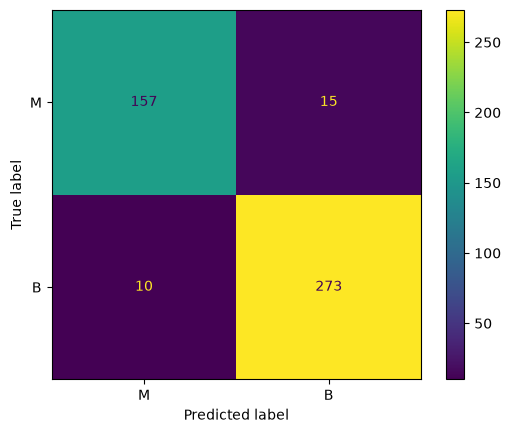

In [5]:
# train_y_pred = cross_val_predict(estimator = grid_results.best_estimator_, X = train_X, y = train_y, cv = 5, method = 'predict')
train_y_pred = grid_results.best_estimator_.predict(train_X)
## Confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true = train_y, y_pred = train_y_pred, labels = ['M','B'])

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(train_y, train_y_pred, labels = ['M','B'])
plt.show()

### Part C

In [6]:
print(f"True Positive Rate =", 157 / (157 + 11))
print(f"False Positive Rate =", 11 / (15 + 272))

True Positive Rate = 0.9345238095238095
False Positive Rate = 0.03832752613240418


### Part D

In [7]:
from sklearn.metrics import f1_score, make_scorer

f1_scorer = make_scorer(f1_score, average='binary', pos_label='M')

params = {
    'model__n_neighbors': range(5, 25 + 1, 5),
    'model__weights': ['uniform', 'distance'],
    'scaler': [
        StandardScaler(),
        RobustScaler(),
        'passthrough'
    ]
}

pipe = Pipeline([
    ('scaler', 'passthrough'),
    ('model', KNeighborsClassifier())
])

grid_results_1D = GridSearchCV(
    pipe,
    params,
    cv=5,
    scoring=f1_scorer
).fit(train_X, train_y)
print(f"cross-validated F1 score using the best model is {float(grid_results_1D.best_score_)}.")

cross-validated F1 score using the best model is 0.9233002291825821.


In [8]:
# Select by accuracy
print(f"Select by accuracy (score = {grid_results.best_score_}):")
print(grid_results.best_params_)
print(f"Select by f1 (score = {grid_results_1D.best_score_}):")
print(grid_results_1D.best_params_)

Select by accuracy (score = 0.9428571428571428):
{'model__n_neighbors': 15, 'model__weights': 'uniform', 'scaler': StandardScaler()}
Select by f1 (score = 0.9233002291825821):
{'model__n_neighbors': 15, 'model__weights': 'uniform', 'scaler': StandardScaler()}


### Part E

They picked the same model and so the metric did not influence model selection in this example.

## Question 2

### Part A

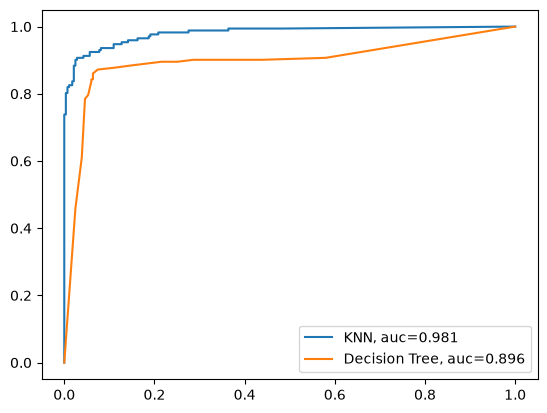

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# KNN model with 15 neighbors and distance weighting using standardization to re-scale the data. 
pipe_knn = Pipeline([
 ('scaler', StandardScaler()),
 ('classifier', KNeighborsClassifier(n_neighbors = 15, weights = 'distance'))
])
# Cross-validated predictions
knn_train_y_pred_prob = cross_val_predict(estimator = pipe_knn, X = train_X, y = train_y, cv = 5, method = 'predict_proba')

# Decision tree with a maximum depth of 4. 
pipe_dt = Pipeline([
 ('scaler', StandardScaler()),
 ('classifier', DecisionTreeClassifier(max_depth = 4))
])
# Cross-validated predictions
dt_train_y_pred_prob = cross_val_predict(estimator = pipe_dt, X = train_X, y = train_y, cv = 5, method = 'predict_proba')

# Display the ROC curves of two different models using their cross-validated predictions. 
from sklearn.metrics import roc_curve, roc_auc_score

## Get ROC curve components and AUC for model 1 - KNN
fpr, tpr, thresh = roc_curve(train_y, knn_train_y_pred_prob[:,1], pos_label = 'M')
auc = roc_auc_score(train_y, knn_train_y_pred_prob[:,1], labels = ['M','B'])

## Same for model 2 - Decision Tree
fpr2, tpr2, thresh2 = roc_curve(train_y, dt_train_y_pred_prob[:,1], pos_label = 'M')
auc2 = roc_auc_score(train_y, dt_train_y_pred_prob[:,1], labels = ['M','B'])

## Create the plot
plt.plot(fpr,tpr,label="KNN, auc="+str(round(auc,3)))
plt.plot(fpr2,tpr2,label="Decision Tree, auc="+str(round(auc2,3)))
plt.legend(loc=0)
plt.show()

### Part B

In [10]:
print(pd.DataFrame({'t': thresh, 'TPR': tpr,'FPR': fpr}))

           t       TPR       FPR
0        inf  0.000000  0.000000
1   1.000000  0.610465  0.000000
2   0.825582  0.738372  0.000000
3   0.814231  0.738372  0.003534
4   0.766708  0.802326  0.003534
5   0.761934  0.802326  0.007067
6   0.746746  0.819767  0.007067
7   0.744562  0.819767  0.010601
8   0.720811  0.825581  0.010601
9   0.703018  0.825581  0.017668
10  0.686570  0.837209  0.017668
11  0.661450  0.837209  0.021201
12  0.568698  0.883721  0.021201
13  0.544024  0.883721  0.024735
14  0.535639  0.901163  0.024735
15  0.525366  0.901163  0.028269
16  0.521085  0.906977  0.028269
17  0.509324  0.906977  0.042403
18  0.498087  0.912791  0.042403
19  0.423217  0.912791  0.056537
20  0.416844  0.924419  0.056537
21  0.400250  0.924419  0.077739
22  0.392982  0.930233  0.077739
23  0.380655  0.930233  0.081272
24  0.371263  0.936047  0.081272
25  0.343437  0.936047  0.109541
26  0.337614  0.947674  0.109541
27  0.301606  0.947674  0.127208
28  0.293618  0.953488  0.127208
29  0.2727

**Comment:** The example from this section used a KNN model with `n_neighbors=8` and `weights='uniform'`, thus probabilities are given in strictly fixed $\dfrac{1}{8}, \dfrac{2}{8},\dfrac{3}{8} ...$, resulting in 8 rows of different thresholds. However, the KNN model in my work used `n_neighbors=15` and `weights='distance'` so there are way more, more than 15 even, of probabilities due to the fact that neighbors contribute according to their distances and distances vary between observations.

### Part C

The highest true positive rate that can be achieved with a false positive rate no larger than 5% is 91.3% at threshold 18.

## Question 3

In [11]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=3000, n_features=10, n_informative=4, n_redundant=2, n_clusters_per_class=2, 
                           weights=[0.95, 0.05],class_sep=0.9,random_state=123)

### Part A

In [12]:
# KNN classifer (using default arguments and a standard scaler to prepare the data)
pipe_knn = Pipeline([
 ('scaler', StandardScaler()),
 ('classifier', KNeighborsClassifier())
])
# Cross-validated predictions
knn_train_y_pred_prob = cross_val_predict(estimator = pipe_knn, X = X, y = y, cv = 5, method = 'predict_proba')

# Decision tree classifier (using max_depth=4)
pipe_dt = Pipeline([
 ('scaler', StandardScaler()),
 ('classifier', DecisionTreeClassifier(max_depth = 4))
])
# Cross-validated predictions
dt_train_y_pred_prob = cross_val_predict(estimator = pipe_dt, X = X, y = y, cv = 5, method = 'predict_proba')


### Part B

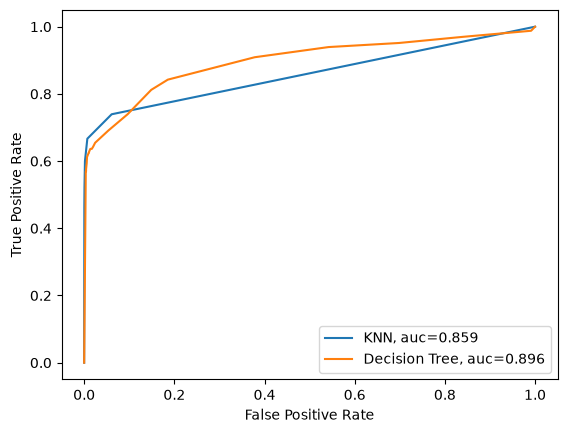

In [13]:
## Get ROC curve components and AUC for model 1 - KNN
fpr, tpr, thresh = roc_curve(y, knn_train_y_pred_prob[:,1])
auc = roc_auc_score(y, knn_train_y_pred_prob[:,1])

## Same for model 2 - Decision Tree
fpr2, tpr2, thresh2 = roc_curve(y, dt_train_y_pred_prob[:,1])
auc2 = roc_auc_score(y, dt_train_y_pred_prob[:,1])

## Create the plot
plt.plot(fpr,tpr,label="KNN, auc="+str(round(auc,3)))
plt.plot(fpr2,tpr2,label="Decision Tree, auc="+str(round(auc2,3)))
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.legend(loc=0)
plt.show()

### Part C

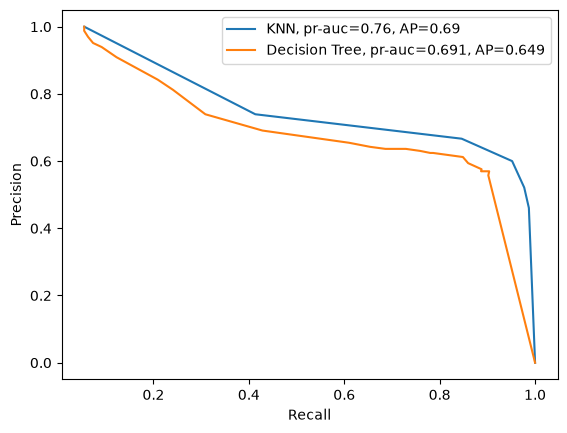

In [14]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
## Get PR curve components and AUC for model 1 - KNN
pre, rec, thresholds = precision_recall_curve(y, knn_train_y_pred_prob[:,1])
pr_auc = auc(rec, pre)
ap = average_precision_score(y, knn_train_y_pred_prob[:,1])

## Same for model 2 - Decision Tree
pre2, rec2, thresholds2 = precision_recall_curve(y, dt_train_y_pred_prob[:,1])
pr_auc2 = auc(rec2, pre2)
ap2 = average_precision_score(y, dt_train_y_pred_prob[:,1])

## Create the plot
plt.plot(pre,rec,label=f"KNN, pr-auc={str(round(pr_auc,3))}, AP={str(round(ap,3))}")
plt.plot(pre2,rec2,label=f"Decision Tree, pr-auc={str(round(pr_auc2,3))}, AP={str(round(ap2,3))}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc=0)
plt.show()

### Part D

The ROC-AUC and PR-AUC metrics did not rank the two models the same way. ROC-AUC favors Decision Tree while PR-AUC favors KNN. The difference is because the two metrics are different in what they measure, ROC-AUC is interested in performance across a range of classification while PR-AUC is when we have rare positive class and is interested in accurate detection of the positive class across a range of classification thresholds. For this application, I would prefer PR-AUC because our dataset is generated to have a rare positive class (only 5% of observations), and we deem the positive class to be important. Thus, I would prefer the KNN model.

## Question 4

In [15]:
## The Wi-Fi positioning data
wifi = pd.read_csv("https://remiller1450.github.io/data/wifi.csv")
wifi.head(5)

,S1,S2,S3,S4,S5,S6,S7,Room
0,-64,-56,-61,-66,-71,-82,-81,1
1,-68,-57,-61,-65,-71,-85,-85,1
2,-63,-60,-60,-67,-76,-85,-84,1
3,-61,-60,-68,-62,-77,-90,-80,1
4,-63,-65,-60,-63,-77,-81,-87,1


### Part A

Missing values count in wifi_train S1      0
S2      0
S3      0
S4      0
S5      0
S6      0
S7      0
Room    0
dtype: int64

Duplicate rows: 0


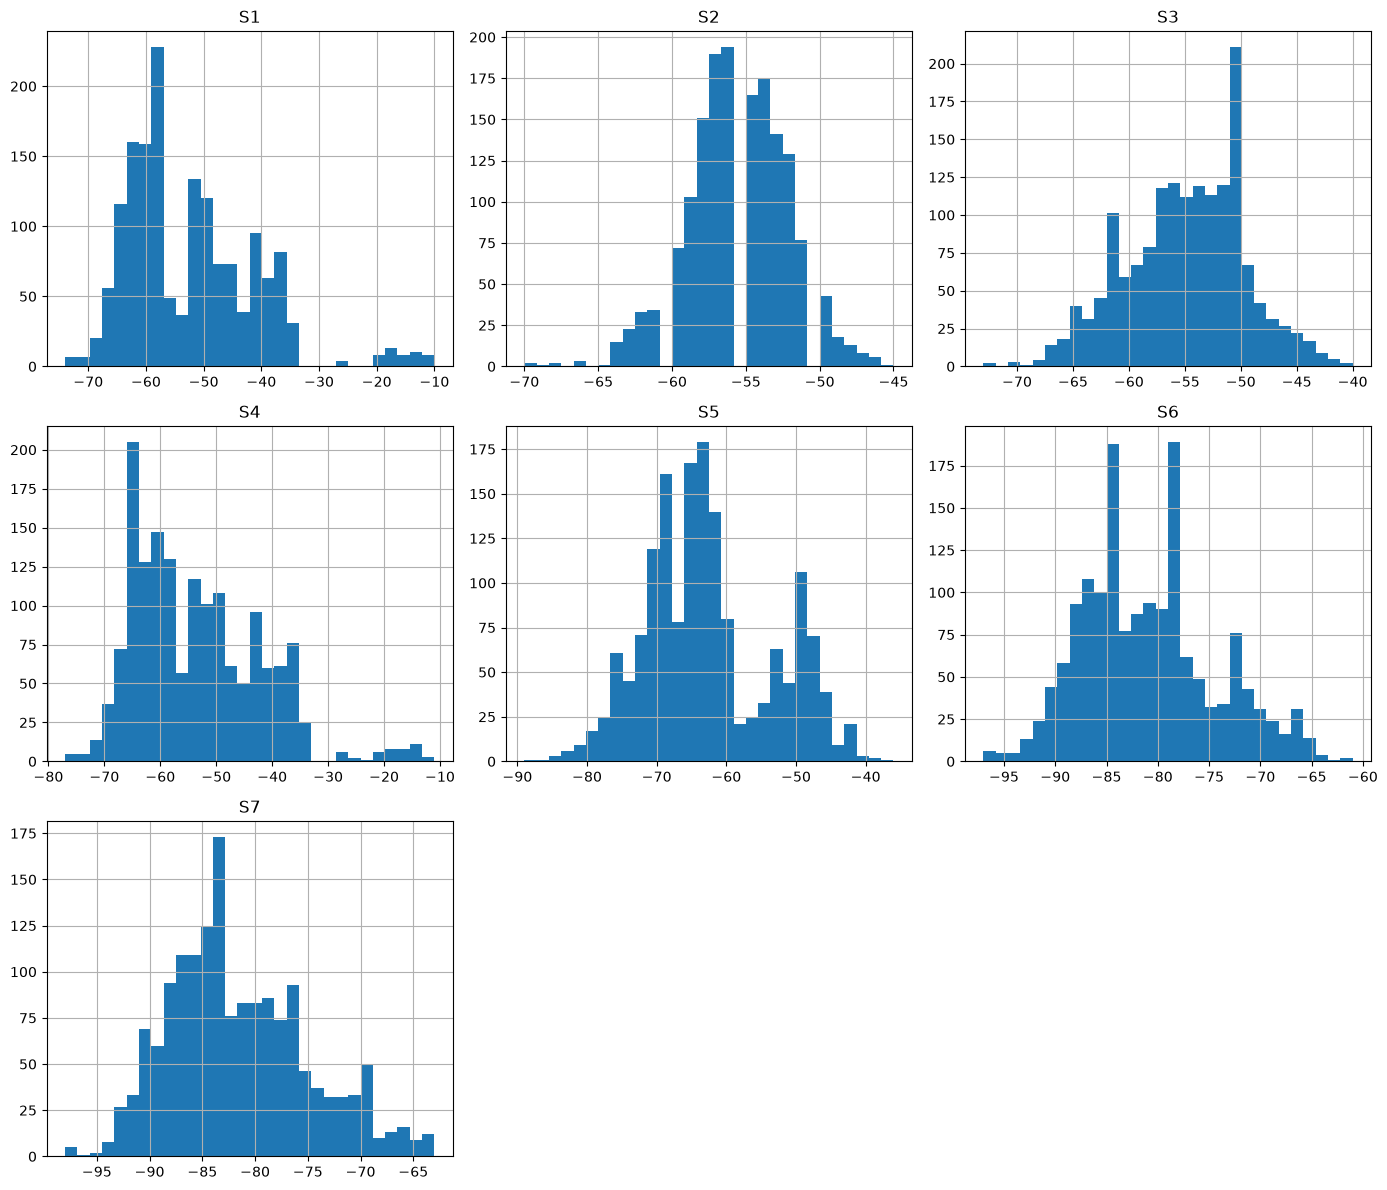

In [16]:
# Separate test/train split with 80-20 ratio and random state = 12
wifi_train, wifi_test = train_test_split(wifi, test_size=0.2, random_state=12)

# Separate the predictor from the outcome
wifi_y_test = wifi_test['Room']
wifi_y_train = wifi_train['Room']
wifi_X_train = wifi_train.drop(['Room'], axis=1)
wifi_X_test = wifi_test.drop(['Room'], axis=1)

# Missing values
print(f"Missing values count in wifi_train {wifi_train.isna().sum()}")

# 
print("\nDuplicate rows:", wifi_train.duplicated().sum())

# Graph a histogram of every predictors
wifi_X_train.hist(figsize=(14,12), bins = 30)
plt.tight_layout()
plt.show()

**Comment:** There is no missing value or duplicated rows. Looking at the distributions, S1 and S4 looks a bit left-skewed, S2 looks like there is some low-value extreme but overall bell-shaped, the rest looks normal except for some peaks.

### Part B

In [ ]:
params4b = [
    {
        'model': [KNeighborsClassifier()],
        'model__n_neighbors': [2, 4, 8],
        'model__weights': ['uniform', 'distance'],
        'scaler': [StandardScaler(), RobustScaler()]
    },
    {
        'model': [DecisionTreeClassifier(random_state=12)],
        'model__max_depth': [2, 4, 6, 8],
        'scaler': ['passthrough']
    }
]

pipe4b = Pipeline([
    ('scaler', 'passthrough'),
    ('model', KNeighborsClassifier())
])

grid_results4b = GridSearchCV(
    pipe4b,
    params4b,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # run parallel otherwise it will take forever
).fit(wifi_X_train, wifi_y_train)

params_to_print = [
    'param_model',
    'param_scaler',
    'param_model__n_neighbors',
    'param_model__weights',
    'param_model__max_depth',
    'mean_test_score'
]

pd.DataFrame(grid_results4b.cv_results_).sort_values(by='mean_test_score', ascending=False)[params_to_print].head(5)

,param_model,param_scaler,param_model__n_neighbors,param_model__weights,param_model__max_depth,mean_test_score
4,KNeighborsClassifier(),StandardScaler(),4.0,uniform,NaN,0.981875
5,KNeighborsClassifier(),RobustScaler(),4.0,uniform,NaN,0.981875
3,KNeighborsClassifier(),RobustScaler(),2.0,distance,NaN,0.980625
6,KNeighborsClassifier(),StandardScaler(),4.0,distance,NaN,0.980625
7,KNeighborsClassifier(),RobustScaler(),4.0,distance,NaN,0.980625


### Part C

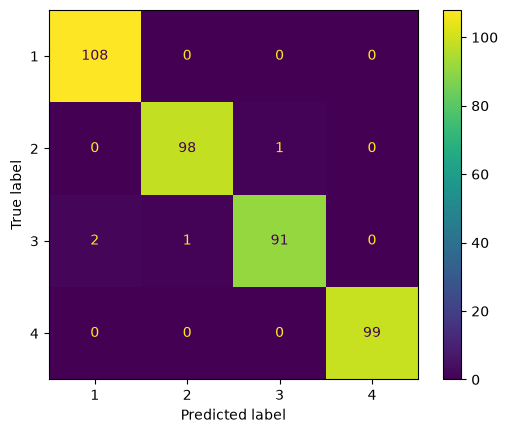

In [18]:
test_y_pred = grid_results4b.best_estimator_.predict(wifi_X_test)

## Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(wifi_y_test, test_y_pred, labels=grid_results4b.best_estimator_.classes_)
plt.show()

**Comment:** The best classification method was best with class 1 and 4 (correctly identifying 108 and 99 observations) and was worst with class 3, having the lowest correct classification of 91 (2 of which got classified as class 1, 1 of which got classified as class 2). 

### Part D

In [19]:
grid_results4d = GridSearchCV(
    pipe4b,
    params4b,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
).fit(wifi_X_train, wifi_y_train)

pd.DataFrame(grid_results4d.cv_results_).sort_values(by='mean_test_score', ascending=False)[params_to_print].head(5)

,param_model,param_scaler,param_model__n_neighbors,param_model__weights,param_model__max_depth,mean_test_score
5,KNeighborsClassifier(),RobustScaler(),4.0,uniform,NaN,0.981980
4,KNeighborsClassifier(),StandardScaler(),4.0,uniform,NaN,0.981968
7,KNeighborsClassifier(),RobustScaler(),4.0,distance,NaN,0.980745
6,KNeighborsClassifier(),StandardScaler(),4.0,distance,NaN,0.980729
3,KNeighborsClassifier(),RobustScaler(),2.0,distance,NaN,0.980683


In [20]:
print(grid_results4b.best_params_)
print(grid_results4d.best_params_)

{'model': KNeighborsClassifier(), 'model__n_neighbors': 4, 'model__weights': 'uniform', 'scaler': StandardScaler()}
{'model': KNeighborsClassifier(), 'model__n_neighbors': 4, 'model__weights': 'uniform', 'scaler': RobustScaler()}


**Comment:** The change in metric scoring also changes the best model. Both best models are KNN with 4 neighbors, uniform weights. The only difference is that when using accuracy for scoring, the best model used Standard Scaler while when using f1-macro, we got Robust Scaler. I suspect this is because standard scaler improve correct predictions overall while robust scaler gives a better balance of precision and recall, and for a model sensitive to re-scaling like KNN and two different metrics like accuracy and f1-macro, we got different results.

### Part E

In [21]:
from sklearn.metrics import accuracy_score
test_y_pred = grid_results4d.best_estimator_.predict(wifi_X_test)
print(accuracy_score(wifi_y_test, test_y_pred))
print(f1_score(wifi_y_test, test_y_pred, average='macro'))

0.995
0.9949193162662011
